In [7]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
import xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import os

## August 2025 (No fire scenario)

In [8]:
# Read 2025 (No fire) NO2 data for study area
band_path01 = 'data_gee/NO2tropMed_0225_float_study_area.tif' # Median data
ds_path01 = xr.open_dataset(band_path01, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path02 = 'data_gee/NO2tropStd_0225_float_study_area.tif'
ds_path02 = xr.open_dataset(band_path02, engine="rasterio", masked=True)

band_path03 = 'data_gee/NO2tropN_0225_float_study_area.tif'
ds_path03 = xr.open_dataset(band_path03, engine="rasterio", masked=True)



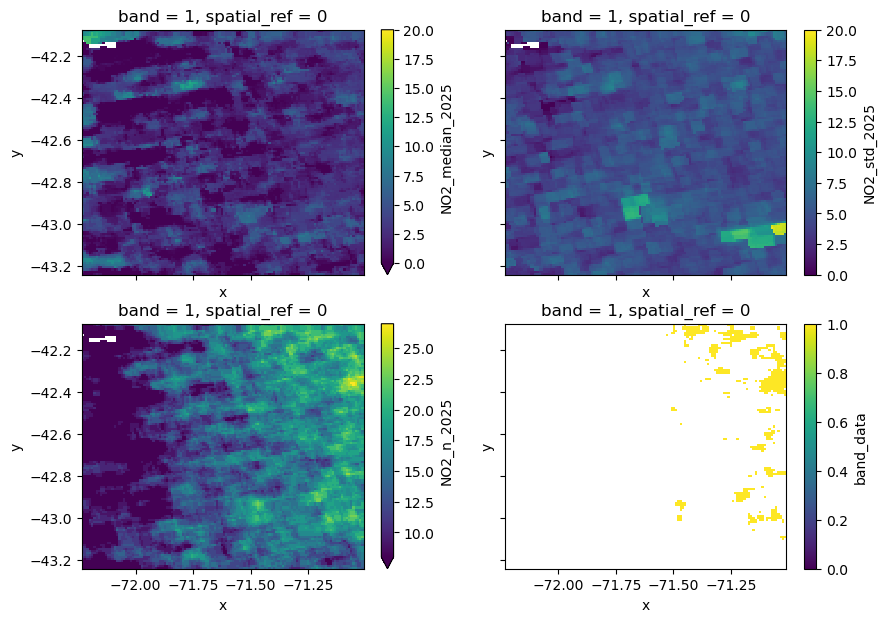

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharey=True, sharex=True)

ds_path01.band_data.plot(ax=ax[0, 0], vmin=0, vmax=20)
ds_path02.band_data.plot(ax=ax[0, 1], vmin=0, vmax=20)
ds_path03.band_data.plot(ax=ax[1, 0], vmin=8)
xr.where(ds_path02.band_data/ds_path01.band_data > 0.5, 1, 0).where(ds_path03.band_data > 20).plot(ax=ax[1, 1], vmin=0, vmax=1)

# mediana > sd ==> poca variabilidad
# mediana < sd ==> alta variabilidad

## January 2026 (Fire scenario)

In [10]:
# Read 2026 (fire) NO2 mean data for study area
band_path04 = 'data_gee/NO2tropMed_0126_float_study_area.tif' # Median data
ds_path04 = xr.open_dataset(band_path04, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path05 = 'data_gee/NO2tropStd_0126_float_study_area.tif'
ds_path05 = xr.open_dataset(band_path05, engine="rasterio", masked=True)

band_path06 = 'data_gee/NO2tropN_0126_float_study_area.tif'
ds_path06 = xr.open_dataset(band_path06, engine="rasterio", masked=True)

In [20]:
ds_path06.band_data.values.max()

np.float32(34.0)

'\nds_path03.band_data.where(ds_path03.band_data > 20).plot(ax=ax[1, 0], vmin=8)\nxr.where(ds_path02.band_data > ds_path01.band_data, 1, 0).where(ds_path03.band_data > 20).plot(ax=ax[1, 1])\n'

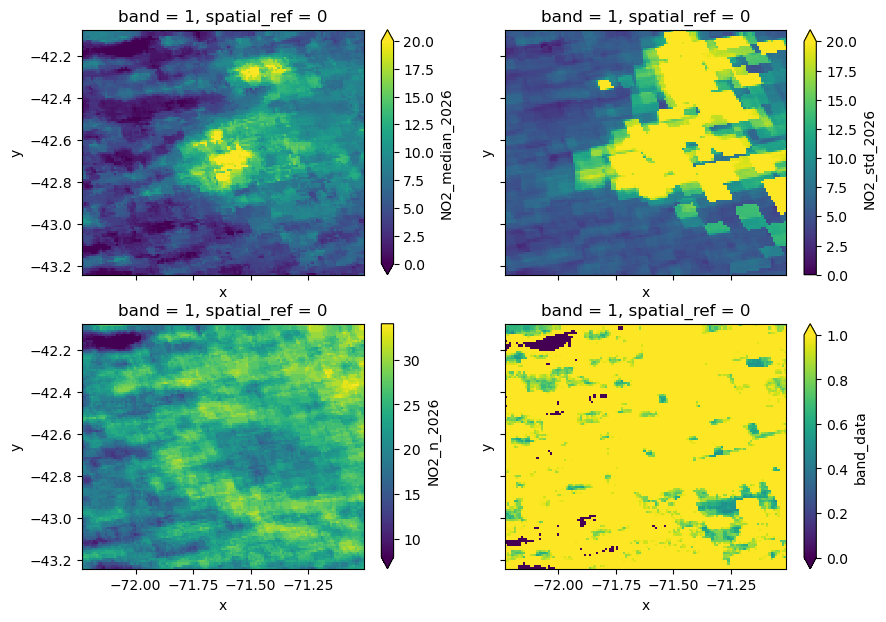

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharey=True, sharex=True)


ds_path04.band_data.plot(ax=ax[0, 0], vmin=0, vmax=20)
ds_path05.band_data.plot(ax=ax[0, 1], vmin=0, vmax=20)
ds_path06.band_data.plot(ax=ax[1, 0], vmin=8)
#xr.where(ds_path05.band_data/ds_path04.band_data>0.5, 1, 0).where(ds_path06.band_data > 20).plot(ax=ax[1, 1])
(ds_path05.band_data/ds_path04.band_data).plot(ax=ax[1, 1], vmin=0, vmax=1)


'''
ds_path03.band_data.where(ds_path03.band_data > 20).plot(ax=ax[1, 0], vmin=8)
xr.where(ds_path02.band_data > ds_path01.band_data, 1, 0).where(ds_path03.band_data > 20).plot(ax=ax[1, 1])
'''
#(ds_path06.band_data).plot(ax=ax[1, 0], vmin=8)

## Aug 2025 vs Jan 2026 difference

In [33]:
diff_2525 = (ds_path04.band_data-ds_path01.band_data)/ds_path01.band_data

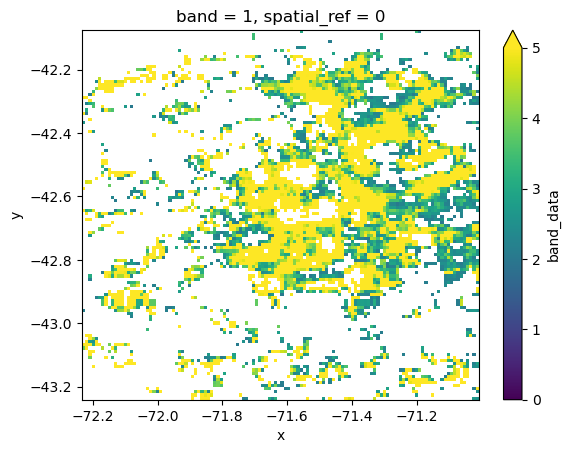

In [41]:
diff_2525.where(diff_2525 > 2).plot(vmin=0, vmax=5)